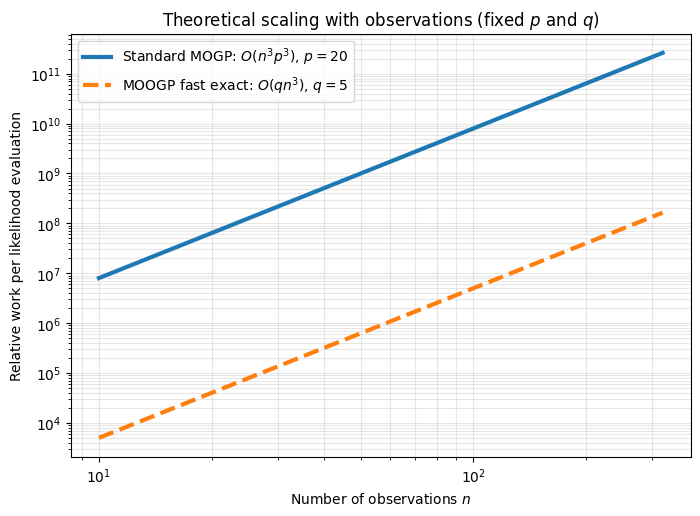

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Fix p and q, then compare scaling with n
# Standard MOGP: O(n^3 p^3)
# Fast exact MOOGP: O(q n^3)

n = np.array([10, 20, 40, 80, 160, 320])
p = 20
q = 5   # change if you want a more conservative or more realistic latent rank

standard_mogp = (n**3) * (p**3)
moogp = q * (n**3)

plt.figure(figsize=(8, 5.5))
plt.loglog(n, standard_mogp, linewidth=3, label=rf"Standard MOGP: $O(n^3 p^3)$, $p={p}$")
plt.loglog(n, moogp, linewidth=3, linestyle="--", label=rf"MOOGP fast exact: $O(qn^3)$, $q={q}$")

plt.xlabel("Number of observations $n$")
plt.ylabel("Relative work per likelihood evaluation")
plt.title(r"Theoretical scaling with observations (fixed $p$ and $q$)")
plt.grid(True, which="both", alpha=0.3)
plt.legend(frameon=True)
plt.show()

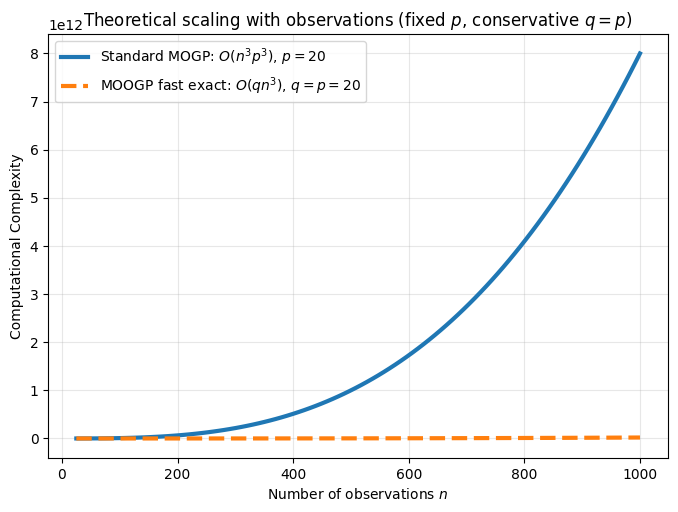

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Conservative comparison: q = p
# Standard MOGP: O(n^3 p^3)
# Fast exact MOOGP: O(q n^3) = O(p n^3)

n = np.linspace(start=25, stop=1000, num=100)
p = 20
q = p

standard_mogp = (n**3) * (p**3)
moogp = q * (n**3)

plt.figure(figsize=(8, 5.5))

plt.plot(n, standard_mogp, linewidth=3, label=rf"Standard MOGP: $O(n^3 p^3)$, $p={p}$")
plt.plot(n, moogp, linewidth=3, linestyle="--", label=rf"MOOGP fast exact: $O(qn^3)$, $q=p={p}$")

plt.xlabel("Number of observations $n$")
plt.ylabel("Computational Complexity")
plt.title(r"Theoretical scaling with observations (fixed $p$, conservative $q=p$)")
plt.grid(True, which="both", alpha=0.3)
plt.legend(frameon=True)
plt.show()

MOGP:
  fitted model: t(n) = 0.003325 * n^1.725768
  exponent x = 1.725768
  log-log R^2 = 0.9542

MOOGP:
  fitted model: t(n) = 0.060150 * n^1.088142
  exponent x = 1.088142
  log-log R^2 = 0.9382



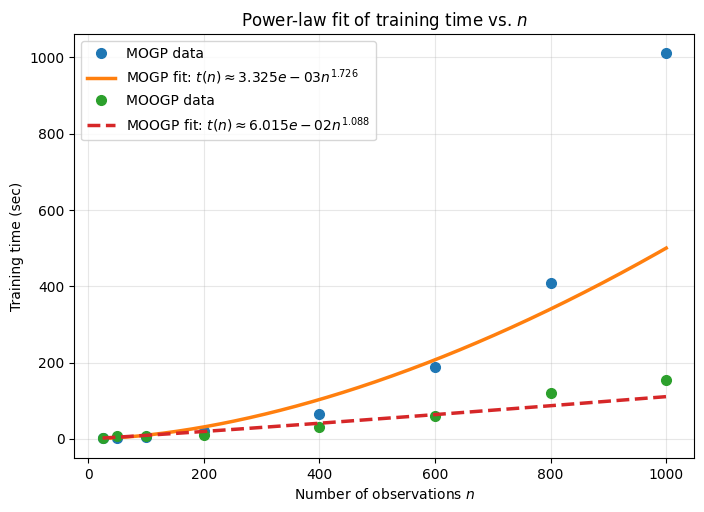

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO

csv_text = """run_id,function,method,n,p,q,rep,seed_data,seed_model,status,error,train_time_sec,pred_time_sec,nit,njev,nfev,rmse,coverage_95,interval_len_95,dss_diag,dss_full
run_3103188650,borehole,MOGP,25,10,10,1,3135672157,2388283801,ok,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH,1.8978059170185588,0.03913116699550301,393,417,417,78.09483143765299,0.8588,138.85998156353887,74.952776326466,
run_3103188650,borehole,MOGP,50,10,10,1,570193007,2584670925,ok,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH,2.2801369169610552,0.06265795801300555,323,346,346,59.47593842115747,0.9176,116.43737171611693,63.41935730815854,
run_3103188650,borehole,MOGP,100,10,10,1,3907457079,1037921756,ok,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH,5.573427083028946,0.15761754103004932,318,340,340,40.63855099239166,0.9288,96.84494800451729,62.533729444120674,
run_3103188650,borehole,MOGP,200,10,10,1,1609578281,919629007,ok,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH,20.83245587500278,0.28605362499365583,554,594,594,37.47174834949458,0.9348,90.71864376048438,60.764069465541155,
run_3103188650,borehole,MOGP,400,10,10,1,1244802814,589735779,ok,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH,66.03058216598583,0.5531877920147963,444,471,471,26.470919633288418,0.9404,71.18859641996067,56.27924160713294,
run_3103188650,borehole,MOGP,600,10,10,1,3223205873,2894752394,ok,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH,189.36018545902334,0.8156338749686256,571,606,606,31.728516769166035,0.948,83.8938477512768,56.676318476596464,
run_3103188650,borehole,MOGP,800,10,10,1,2291229617,2509650496,ok,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH,408.218830415979,1.3118644999922253,641,680,680,35.65320459257679,0.9484,87.0411465350057,58.11014294831663,
run_3103188650,borehole,MOGP,1000,10,10,1,1402259501,1456043139,ok,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH,1010.3951824170072,1.7127270409837365,983,1024,1024,33.58327605940595,0.9464,90.7012057088184,59.59408373297864,
run_3512303396,borehole,MOOGP,25,10,5,1,3135672157,641940974,ok,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH,2.377869749965612,0.020685208961367607,104,119,119,68.34955593298255,0.8524,114.44990590691249,72.46273073344993,
run_3512303396,borehole,MOOGP,50,10,5,1,570193007,394898355,ok,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH,6.273390582995489,0.03340074996231124,276,311,311,56.854334079091245,0.9236,113.48933568154634,62.94328777105974,
run_3512303396,borehole,MOOGP,100,10,5,1,3907457079,910537350,ok,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH,7.256147833017167,0.1003652919898741,241,278,278,39.86255240341717,0.9176,92.65394291672497,62.91708463375815,
run_3512303396,borehole,MOOGP,200,10,5,1,1609578281,2647272286,ok,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH,9.471374542044941,0.17617954197339714,249,265,265,36.71791842014754,0.9332,89.46834331077288,60.743967576065444,
run_3512303396,borehole,MOOGP,400,10,5,1,1244802814,1524451828,ok,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH,32.20380399998976,0.35056799999438226,582,642,642,25.711031146148414,0.94,69.03641928347241,56.03120519902295,
run_3512303396,borehole,MOOGP,600,10,5,1,3223205873,3535756175,ok,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH,59.76208408299135,0.5039633340202272,250,268,268,31.698287701570088,0.9476,84.05902122298733,56.68460251076039,
run_3512303396,borehole,MOOGP,800,10,5,1,2291229617,3723649422,ok,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH,120.30181045900099,0.7315471670008264,288,309,309,35.63066941231743,0.9492,87.25753520897317,58.08889572699471,
run_3512303396,borehole,MOOGP,1000,10,5,1,1402259501,3173453976,ok,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH,153.57154408300994,0.9914869589847513,243,265,265,33.469255730201944,0.9472,90.68597727629798,59.583359221673525,
"""

df = pd.read_csv(StringIO(csv_text))

def fit_power_law(n, t):
    """
    Fit t = c * n^x by linear regression on logs.
    Returns x, c, and R^2 on the log scale.
    """
    log_n = np.log(n)
    log_t = np.log(t)

    x, log_c = np.polyfit(log_n, log_t, 1)
    c = np.exp(log_c)

    log_t_hat = log_c + x * log_n
    ss_res = np.sum((log_t - log_t_hat) ** 2)
    ss_tot = np.sum((log_t - np.mean(log_t)) ** 2)
    r2 = 1 - ss_res / ss_tot

    return x, c, r2

fits = {}

for method in ["MOGP", "MOOGP"]:
    g = df[df["method"] == method].sort_values("n")
    n = g["n"].to_numpy()
    t = g["train_time_sec"].to_numpy()

    x, c, r2 = fit_power_law(n, t)
    fits[method] = {"x": x, "c": c, "r2": r2, "n": n, "t": t}

    print(f"{method}:")
    print(f"  fitted model: t(n) = {c:.6f} * n^{x:.6f}")
    print(f"  exponent x = {x:.6f}")
    print(f"  log-log R^2 = {r2:.4f}")
    print()

# Smooth curves
n_smooth = np.linspace(df["n"].min(), df["n"].max(), 400)

plt.figure(figsize=(8, 5.5))

for method, linestyle in [("MOGP", "-"), ("MOOGP", "--")]:
    n = fits[method]["n"]
    t = fits[method]["t"]
    x = fits[method]["x"]
    c = fits[method]["c"]

    t_smooth = c * n_smooth**x

    plt.plot(n, t, "o", markersize=7, label=f"{method} data")
    plt.plot(
        n_smooth,
        t_smooth,
        linestyle,
        linewidth=2.5,
        label=fr"{method} fit: $t(n)\approx {c:.3e} n^{{{x:.3f}}}$"
    )

plt.xlabel("Number of observations $n$")
plt.ylabel("Training time (sec)")
plt.title("Power-law fit of training time vs. $n$")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()